<a href="https://colab.research.google.com/github/raushankumar018/MLOps-Lab/blob/main/ex_5_mlops_unit2_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install -q mlflow joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 908.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Step 2 — Load Titanic Dataset
# Upload Titanic dataset from your computer

from google.colab import files
import pandas as pd

uploaded = files.upload()

# Get the uploaded file name
file_name = next(iter(uploaded))

# Load the CSV file
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

df.head()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
Dataset loaded successfully!
File: Titanic-Dataset.csv
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# STEP 4 — Load Dataset
# Load the uploaded CSV dataset

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# STEP 5 — Understand the Dataset
# Display dataset information

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Cell 6 — Check Missing Values
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# STEP 6 — Validate Required Columns
# Validate required columns

required_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Survived"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if len(missing_columns) == 0:
    print("✅ All required columns are present.")
else:
    print("❌ Missing columns:", missing_columns)

✅ All required columns are present.


In [ ]:
# STEP 7 — Select Features and Target
# Define input features and target

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Features:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Feature shape: (891, 7)
Target shape: (891,)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
# STEP 8 — Train-Test Split
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [ ]:
# STEP 9 — Create Preprocessing Pipeline
# Define numerical and categorical features

numerical_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [ ]:
# Numerical preprocessing

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# STEP 10 — Train Baseline Random Forest
# Create baseline Random Forest pipeline

baseline_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

print("Baseline pipeline created.")

Baseline pipeline created.


In [ ]:
# STEP 11 — Train Baseline Model
# Train baseline model

start_time = time.time()

baseline_pipeline.fit(X_train, y_train)

baseline_runtime = time.time() - start_time

print(f"Baseline training completed in {baseline_runtime:.2f} seconds.")

Baseline training completed in 1.29 seconds.


In [ ]:
# STEP 12 — Evaluate Baseline
# Make baseline predictions

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Test Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Test Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Test Accuracy: 0.7933
Baseline Test Accuracy: 79.33%


In [ ]:
# Baseline classification report

print("Baseline Classification Report:")
print(
    classification_report(
        y_test,
        baseline_predictions
    )
)

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
# STEP 13 — Grid Search
# Create pipeline for Grid Search

grid_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [ ]:
# Define Grid Search hyperparameters

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Grid Search parameter combinations:", 36)

Grid Search parameter combinations: 36


In [ ]:
# STEP 14 — Run Grid Search
# Perform Grid Search with 5-fold cross-validation

start_time = time.time()

grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

grid_runtime = time.time() - start_time

print(f"\nGrid Search completed in {grid_runtime:.2f} seconds.")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Grid Search completed in 53.21 seconds.


In [ ]:
# STEP 15 — Display Best Grid Parameters
# Display best Grid Search parameters

print("Best Grid Search Parameters:")
print(grid_search.best_params_)

print("\nBest Grid Search CV Accuracy:")
print(f"{grid_search.best_score_:.4f}")
print(f"{grid_search.best_score_ * 100:.2f}%")

Best Grid Search Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Best Grid Search CV Accuracy:
0.8273
82.73%


In [ ]:
# STEP 16 — Evaluate Grid Search on Test Set
# Evaluate best Grid Search model on untouched test set

grid_predictions = grid_search.predict(X_test)

grid_accuracy = accuracy_score(
    y_test,
    grid_predictions
)

print(f"Grid Search Test Accuracy: {grid_accuracy:.4f}")
print(f"Grid Search Test Accuracy: {grid_accuracy * 100:.2f}%")

Grid Search Test Accuracy: 0.7989
Grid Search Test Accuracy: 79.89%


In [ ]:
# Grid Search classification report

print("Grid Search Classification Report:")

print(
    classification_report(
        y_test,
        grid_predictions
    )
)

Grid Search Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [ ]:
# STEP 17 — Random Search
# Create pipeline for Random Search

random_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [ ]:
# STEP 18 — Define Random Search Space
# Define Random Search parameter space

random_param_grid = {
    "model__n_estimators": [50, 100, 150, 200, 250, 300],
    "model__max_depth": [None, 5, 10, 15, 20, 25, 30],
    "model__min_samples_split": [2, 3, 5, 7, 10],
    "model__min_samples_leaf": [1, 2, 3, 4, 5],
    "model__max_features": ["sqrt", "log2", None]
}

print("Random Search parameter space created.")

Random Search parameter space created.


In [ ]:
# STEP 19 — Run Random Search
# Perform Randomized Search with 5-fold cross-validation

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=random_pipeline,
    param_distributions=random_param_grid,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

random_runtime = time.time() - start_time

print(f"\nRandom Search completed in {random_runtime:.2f} seconds.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Search completed in 58.25 seconds.


In [ ]:
# STEP 20 — Display Best Random Parameters
# Display best Random Search parameters

print("Best Random Search Parameters:")
print(random_search.best_params_)

print("\nBest Random Search CV Accuracy:")
print(f"{random_search.best_score_:.4f}")
print(f"{random_search.best_score_ * 100:.2f}%")

Best Random Search Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 30}

Best Random Search CV Accuracy:
0.8301
83.01%


In [ ]:
# STEP 21 — Evaluate Random Search
# Evaluate Random Search model

random_predictions = random_search.predict(X_test)

random_accuracy = accuracy_score(
    y_test,
    random_predictions
)

print(f"Random Search Test Accuracy: {random_accuracy:.4f}")
print(f"Random Search Test Accuracy: {random_accuracy * 100:.2f}%")

Random Search Test Accuracy: 0.7821
Random Search Test Accuracy: 78.21%


In [ ]:
# Random Search classification report

print("Random Search Classification Report:")

print(
    classification_report(
        y_test,
        random_predictions
    )
)

Random Search Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
# STEP 22 — Compare All Models
# Create model comparison table

comparison = pd.DataFrame({
    "Method": [
        "Baseline",
        "Grid Search",
        "Random Search"
    ],

    "CV Accuracy": [
        np.nan,
        grid_search.best_score_,
        random_search.best_score_
    ],

    "Test Accuracy": [
        baseline_accuracy,
        grid_accuracy,
        random_accuracy
    ],

    "Runtime (seconds)": [
        baseline_runtime,
        grid_runtime,
        random_runtime
    ]
})

comparison["Test Accuracy (%)"] = (
    comparison["Test Accuracy"] * 100
)

comparison

,Method,CV Accuracy,Test Accuracy,Runtime (seconds),Test Accuracy (%)
0,Baseline,NaN,0.793296,1.287770,79.329609
1,Grid Search,0.827342,0.798883,53.207273,79.888268
2,Random Search,0.830139,0.782123,58.253824,78.212291


In [ ]:
# STEP 23 — Calculate Improvement
# Calculate improvement over baseline

grid_improvement = (
    grid_accuracy - baseline_accuracy
) * 100

random_improvement = (
    random_accuracy - baseline_accuracy
) * 100

print(
    f"Grid Search improvement: "
    f"{grid_improvement:.2f} percentage points"
)

print(
    f"Random Search improvement: "
    f"{random_improvement:.2f} percentage points"
)

Grid Search improvement: 0.56 percentage points
Random Search improvement: -1.12 percentage points


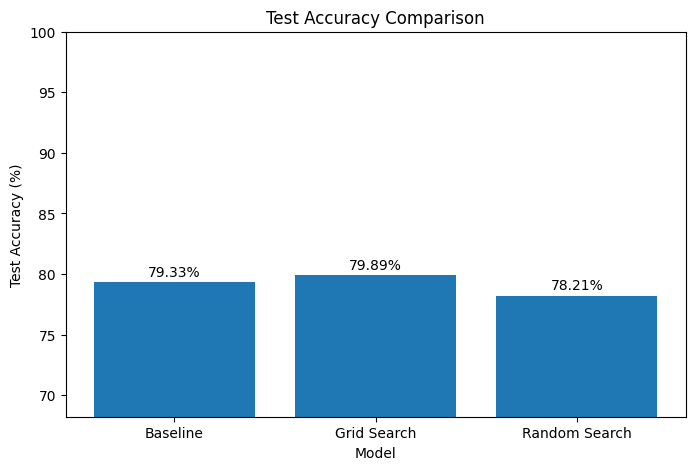

In [ ]:
# STEP 24 — Accuracy Comparison Graph
# Plot test accuracy comparison

methods = [
    "Baseline",
    "Grid Search",
    "Random Search"
]

accuracies = [
    baseline_accuracy * 100,
    grid_accuracy * 100,
    random_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(methods, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")

plt.ylim(
    max(0, min(accuracies) - 10),
    100
)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [ ]:
# STEP 25 — Top Grid Search Configurations
# Get Grid Search results

grid_results = pd.DataFrame(
    grid_search.cv_results_
)

top_grid_results = (
    grid_results
    .sort_values(
        by="mean_test_score",
        ascending=False
    )
    .head(10)
)

top_grid_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf"
    ]
]

,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf
33,0.827342,0.031656,50,10,5,2
8,0.827332,0.028805,200,None,2,2
35,0.827332,0.027013,200,10,5,2
32,0.827322,0.024410,200,10,2,2
7,0.827322,0.027828,100,None,2,2
34,0.825933,0.028657,100,10,5,2
10,0.825914,0.029131,100,None,5,2
29,0.825904,0.025950,200,10,5,1
11,0.824525,0.029905,200,None,5,2
28,0.824505,0.027259,100,10,5,1


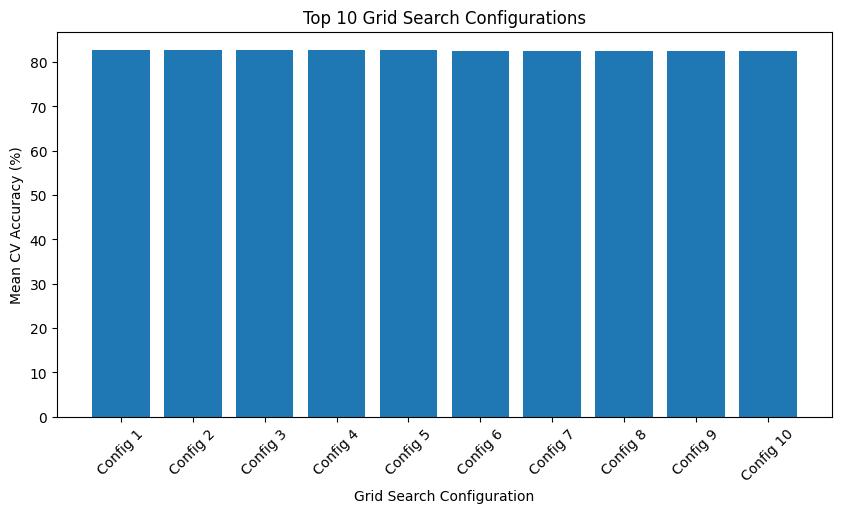

In [ ]:
# STEP 26 — Plot Top Configurations
# Plot top 10 Grid Search configurations

top_scores = (
    top_grid_results["mean_test_score"] * 100
).values

labels = [
    f"Config {i+1}"
    for i in range(len(top_scores))
]

plt.figure(figsize=(10, 5))

plt.bar(labels, top_scores)

plt.xlabel("Grid Search Configuration")
plt.ylabel("Mean CV Accuracy (%)")
plt.title("Top 10 Grid Search Configurations")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# STEP 27 — Select Final Model
# Select the model with the highest test accuracy

model_results = {
    "Baseline": baseline_accuracy,
    "Grid Search": grid_accuracy,
    "Random Search": random_accuracy
}

best_method = max(
    model_results,
    key=model_results.get
)

best_accuracy = model_results[best_method]

print("Selected final model:", best_method)
print(f"Test Accuracy: {best_accuracy * 100:.2f}%")

Selected final model: Grid Search
Test Accuracy: 79.89%


In [ ]:
# STEP 28 — Select Pipeline to Save
# Select the corresponding trained pipeline

if best_method == "Baseline":
    final_model = baseline_pipeline

elif best_method == "Grid Search":
    final_model = grid_search.best_estimator_

else:
    final_model = random_search.best_estimator_

print("Final model selected successfully.")

Final model selected successfully.


In [ ]:
# STEP 29 — Save Model
# Save the complete ML pipeline

model_filename = "best_titanic_random_forest.pkl"

joblib.dump(
    final_model,
    model_filename
)

print(f"Model saved successfully as: {model_filename}")

Model saved successfully as: best_titanic_random_forest.pkl


In [ ]:
# STEP 30 — Load Saved Model
# Load the saved model

loaded_model = joblib.load(
    model_filename
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [ ]:
# STEP 31 — Sample Prediction
# Create sample passenger data

sample_passengers = pd.DataFrame({
    "Pclass": [1, 3],
    "Sex": ["female", "male"],
    "Age": [25, 30],
    "SibSp": [0, 0],
    "Parch": [0, 0],
    "Fare": [80.0, 10.0],
    "Embarked": ["S", "S"]
})

sample_passengers

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,female,25,0,0,80.0,S
1,3,male,30,0,0,10.0,S


In [ ]:
# Predict using the saved model

sample_predictions = loaded_model.predict(
    sample_passengers
)

print("Sample Predictions:")

for i, prediction in enumerate(sample_predictions):

    result = (
        "Survived"
        if prediction == 1
        else "Did Not Survive"
    )

    print(
        f"Passenger {i+1}: {result}"
    )

Sample Predictions:
Passenger 1: Survived
Passenger 2: Did Not Survive


In [ ]:
# Final practical results

print("=" * 60)
print("FINAL MLOPS PRACTICAL RESULTS")
print("=" * 60)

print(f"Dataset: Titanic")
print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Grid Search CV Accuracy: {grid_search.best_score_ * 100:.2f}%")
print(f"Grid Search Test Accuracy: {grid_accuracy * 100:.2f}%")
print(f"Random Search CV Accuracy: {random_search.best_score_ * 100:.2f}%")
print(f"Random Search Test Accuracy: {random_accuracy * 100:.2f}%")

print(f"\nGrid Search Improvement: {grid_improvement:.2f} percentage points")
print(f"Random Search Improvement: {random_improvement:.2f} percentage points")

print(f"\nSelected Model: {best_method}")
print(f"Final Test Accuracy: {best_accuracy * 100:.2f}%")

print(f"\nSaved Model: {model_filename}")

print("=" * 60)

FINAL MLOPS PRACTICAL RESULTS
Dataset: Titanic
Baseline Accuracy: 79.33%
Grid Search CV Accuracy: 82.73%
Grid Search Test Accuracy: 79.89%
Random Search CV Accuracy: 83.01%
Random Search Test Accuracy: 78.21%

Grid Search Improvement: 0.56 percentage points
Random Search Improvement: -1.12 percentage points

Selected Model: Grid Search
Final Test Accuracy: 79.89%

Saved Model: best_titanic_random_forest.pkl


In [ ]:
# STEP 33 — Download Model
# Download the trained model

files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>